In [1]:
using Random, Statistics, Plots, ProgressMeter, JSON, StatsBase, Distributions, GLM, LaTeXStrings, SplitApplyCombine

In [2]:
### Save data to file ###

function save_to_file(file::Any, name::String, vec_of_vec::Bool)
    open(string(name), "w") do io
        if vec_of_vec      
            for mi in file
                println(io, join(mi, ", "))  # comma-separated values
            end
        else
            for mi in file
                println(io, mi)  # comma-separated values
            end
        end
    end
end

save_to_file (generic function with 1 method)

# Structures

## Chromosomes

In [3]:
# Chromosomes Type and Functions
# -------------------------------
mutable struct Chromosomes
    chromosomes_gene_type::Vector{Vector{Int}}
    chromosomes_gene_mut::Vector{Vector{Int}}
    gene_map::Dict{Int,String}
end

function get_Nchrs(ch::Chromosomes)
    if length(ch.chromosomes_gene_type) == length(ch.chromosomes_gene_mut)
        return length(ch.chromosomes_gene_type)
    else
        error("Mismatched chromosome lists.")
    end
end

function get_Ngenes(ch::Chromosomes)
    ngenes = 0
    if length(ch.chromosomes_gene_type) == length(ch.chromosomes_gene_mut)
        for i in 1:length(ch.chromosomes_gene_type)
            if length(ch.chromosomes_gene_type[i]) == length(ch.chromosomes_gene_mut[i])
                ngenes = ngenes+length(ch.chromosomes_gene_type[i])
            else
                error("Mismatched genes lenghts")
            end
        end
        return ngenes
    else
        error("Mismatched chromosome lists.")
    end
end

function mutate!(ch::Chromosomes, mu::Float64)
    n_mut = 0
    for i in 1:get_Nchrs(ch)
        chrom = copy(ch.chromosomes_gene_mut[i])
        # For each gene in the chromosome, mutate with probability mu.
        for j in 1:length(chrom)
            if rand() < mu
                chrom[j] = 1
            end
        end
        ch.chromosomes_gene_mut[i] = chrom
    end
end

function get_genes_by_type(ch::Chromosomes, gene_type::String)
    restr_gene_mut_gt = Vector{Vector{Int}}()
    restr_gene_mut_gm = Vector{Vector{Int}}()
    for i in 1:length(ch.chromosomes_gene_type)
        mapped = [ch.gene_map[x] for x in ch.chromosomes_gene_type[i]]
        inds = findall(x -> x == gene_type, mapped)
        push!(restr_gene_mut_gt, ch.chromosomes_gene_type[i][inds])
        push!(restr_gene_mut_gm, ch.chromosomes_gene_mut[i][inds])
    end
    return restr_gene_mut_gt, restr_gene_mut_gm
end


get_genes_by_type (generic function with 1 method)

## Cell

In [4]:
# Cell Type and Methods
# ---------------------
mutable struct Cell
    x::Int
    y::Int
    chromosomes::Chromosomes
    state::Int
    mu0::Float64
    dmu::Float64
    mu::Float64
    r0::Float64
    dr::Float64
    rmax::Float64
    r::Float64
    dm::Float64
    m::Float64
end

get_Nchrs(cell::Cell) = get_Nchrs(cell.chromosomes)

function dead_cell(x::Int, y::Int)
    return Cell(x,y,Chromosomes([], [], Dict()),2,0,0,0,0,0,0,0,0,0)
end
"""
    compute_activation(cell, gene_type; mode="any")

Helper function that computes, for a given gene type, an activation Boolean vector
across the unique genes. For mode "any", a gene is activated if at least one chromosome
has it mutated; for mode "all", only if all chromosomes show the mutation.
"""
function compute_activation(cell::Cell, gene_type::String; mode::String="any")
    gene_types, gene_muts = get_genes_by_type(cell.chromosomes, gene_type)
    if all(x -> isempty(x), gene_types)
        return Bool[]
    end
    unique_genes = unique(vcat(gene_types...))
    # For each chromosome, build a Boolean vector indicating for each unique gene if any matching gene is mutated.
    if mode == "any"
        # A gene is activated if any chromosome shows it.
        activation = [ [ any(gene_muts[i][findall(x -> x == ug, gene_types[i])] .== 1) for ug in unique_genes ]
                   for i in 1:length(gene_types) ]
        return [ any(activation[i][j] for i in 1:length(activation)) for j in 1:length(unique_genes) ]
    elseif mode == "all"
        # A gene is activated only if every chromosome shows it.
        activation = [ [ all(gene_muts[i][findall(x -> x == ug, gene_types[i])] .== 1) for ug in unique_genes ]
                   for i in 1:length(gene_types) ]
        return [ all(activation[i][j] for i in 1:length(activation)) for j in 1:length(unique_genes) ]
    else
        error("Invalid mode. Use \"any\" or \"all\".")
    end
end

function update_mu!(cell::Cell)
    act = compute_activation(cell, "I"; mode="all")
    new_mu = cell.mu0 + sum(act) * cell.dmu
    cell.mu = cell.mu0 + sum(act) * cell.dmu
end

function update_r!(cell::Cell)
    act_o = compute_activation(cell, "O"; mode="any")
    act_s = compute_activation(cell, "S"; mode="all")
    new_r = cell.r0 + (sum(act_o) + sum(act_s)) * cell.dr
    cell.r = new_r < cell.rmax ? new_r : cell.rmax
end

function update_m!(cell::Cell)
    act_m = compute_activation(cell, "M"; mode="all")
    cell.m = sum(act_m) * cell.dm
end


function check_cell_death(cell::Cell)
    if length(cell.chromosomes.chromosomes_gene_mut) == 0
        return true
    elseif cell.state!=0 && cell.mu==0.
        return true
    elseif any(compute_activation(cell, "HK"; mode="all"))
        return true
    elseif get_Ngenes(cell.chromosomes)>120#5*length(cell.chromosomes.gene_map)
        return true
    elseif get_Nchrs(cell)>7#5*length(cell.chromosomes.gene_map)
        return true
    else
        return false
    end
end

"""
    update!(cell)

Updates the cell state: first checks for cell death, then applies mutation, and updates
the mutation and reproduction rates. Returns 0 if the cell dies, 1 if it reproduces,
or 2 if nothing happens.
"""
function sample_reproducers(rates::Vector{Float64})
    R = sum(rates)
    K = rand(Poisson(R))

    # if no events, short‐circuit:
    if K == 0
        return falses(length(rates)), zeros(Int, length(rates))
    end

    # pick K events (with replacement) weighted by rates:
    events = sample(1:length(rates), Weights(rates), K; replace=false)

    # tabulate
    counts = zeros(Int, length(rates))
    for i in events
        counts[i] += 1
    end
    reproduced = counts .> 0
    return reproduced, events
end


function copy_cell(cell::Cell)
    new_chromosomes = Chromosomes([copy(arr) for arr in cell.chromosomes.chromosomes_gene_type],
                                  [copy(arr) for arr in cell.chromosomes.chromosomes_gene_mut],
                                  deepcopy(cell.chromosomes.gene_map))
    return Cell(cell.x, cell.y, new_chromosomes, cell.state, cell.mu0, cell.dmu, cell.mu, 
                cell.r0, cell.dr, cell.rmax, cell.r, cell.dm, cell.m)
end

copy_cell (generic function with 1 method)

## Tissue

In [5]:
# Tissue Type and Functions
# -------------------------
mutable struct Tissue
    L::Int
    cells::Array{Cell,2}
    gene_map::Dict{Int,String}
    neighbor_cache::Dict{Tuple{Int,Int}, Vector{Tuple{Int,Int}}}
end

function compute_neighbors(L::Int, row::Int, col::Int)
    neighbors = Vector{Tuple{Int,Int}}()
    for dr in -1:1
        for dc in -1:1
            if dr == 0 && dc == 0
                continue
            end
            new_row = row + dr
            new_col = col + dc
            if new_row ≥ 1 && new_row ≤ L && new_col ≥ 1 && new_col ≤ L
                push!(neighbors, (new_row, new_col))
            end
        end
    end
    return neighbors
end

function Tissue(L::Int, init_cell_state::Array{Cell,2})
    gene_map = init_cell_state[1,1].chromosomes.gene_map
    neighbor_cache = Dict{Tuple{Int,Int}, Vector{Tuple{Int,Int}}}()
    for i in 1:L, j in 1:L
        neighbor_cache[(i,j)] = compute_neighbors(L, i, j)
    end
    return Tissue(L, init_cell_state, gene_map, neighbor_cache)
end

get_neighbors(tiss::Tissue, row::Int, col::Int) = tiss.neighbor_cache[(row, col)]

# Tissue Initialization
# --------------------
function init_tissue(L::Int, chrom_gene_type::Vector{Vector{Int}}, chrom_gene_mut::Vector{Vector{Int}},
    gene_map::Dict{Int,String}, 
    mu0::Float64, dmu::Float64, 
    r0::Float64, dr::Float64, rmax::Float64, dm::Float64)
    cells = Array{Cell}(undef, L, L)
    for i in 1:L, j in 1:L
        ch = Chromosomes(copy(chrom_gene_type), copy(chrom_gene_mut), gene_map)
        cells[i,j] = Cell(i, j, ch, 0, mu0, dmu, mu0,
                                    r0, dr, rmax, r0, dm, 0)
    end
    return Tissue(L, cells)
end

# Perturbation of the initial state
# ---------------------------------
function perturb_init_tissue!(tiss::Tissue, r::Float64, pert_chrom_gene_mut::Vector{Vector{Int}})
    L = tiss.L
    for i in 1:L
        for j in 1:L
            if (i-L//2)^2+(j-L//2)^2 <= (r*L)^2
                tiss.cells[i,j].chromosomes.chromosomes_gene_mut = copy(pert_chrom_gene_mut)
                tiss.cells[i,j].state=1
                update_mu!(tiss.cells[i,j])
                update_r!(tiss.cells[i,j])
                update_m!(tiss.cells[i,j])
            end
        end
    end
end


function get_actions(tiss::Tissue)
    actions = zeros(Int, tiss.L, tiss.L)
    actions += reshape(sample_reproducers(vec(get_r(tiss)))[1],tiss.L,tiss.L)  # reproducing cells
    return actions
end

function initialize_tiss_indx!(tiss::Tissue)
    for i in 1:tiss.L, j in 1:tiss.L
        tiss.cells[i,j].x = i
        tiss.cells[i,j].y = j
    end
end

function get_idx(tiss::Tissue)
    idx = zeros(Int, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        idx[i,j] = (tiss.cells[i,j].x) + (tiss.L*(tiss.cells[i,j].y-1))
    end
    return idx
end


function copy_tissue(orig::Tissue)
    L = orig.L
    # Deep-copy every cell
    newcells = [ copy_cell(orig.cells[i,j]) for i in 1:L, j in 1:L ]
    # Rebuild a fresh Tissue (this will re-extract gene_map and rebuild neighbor_cache)
    return Tissue(L, newcells)
end

copy_tissue (generic function with 1 method)

In [6]:
### Tissue update ###

# Helper function for weighted random selection.
function weighted_choice(neighbors::Vector{Tuple{Int,Int}}, weights::Vector{Float64})
    total = sum(weights)
    r = rand() * total
    cum = 0.0
    for (i, w) in enumerate(weights)
        cum += w
        if r < cum
            return neighbors[i]
        end
    end
    return neighbors[end]
end


# small helper to finish off a cell after placement
function _finalize!(cell::Cell, dead_pos::Vector{Tuple{Int,Int}}, i::Int, j::Int, n_chrs::Int)
    mutate!(cell.chromosomes, cell.mu)
    if cell.state == 0
        if get_Nchrs(cell)!=n_chrs
            cell.state=1
        elseif sum(sum(cell.chromosomes.chromosomes_gene_mut))!=0
            cell.state=1
        end
    end
    
    if check_cell_death(cell)
        push!(dead_pos, (i,j))
    else
        update_mu!(cell)
        update_r!(cell)
        update_m!(cell)
    end
end


# exchange of chromosome from mother to daugther during replication
function _combine!(mother::Cell, i::Int, j::Int, daughter::Cell, ci::Int, cj::Int, dead_pos::Vector{Tuple{Int,Int}})
    if rand()<mother.m && length(mother.chromosomes.chromosomes_gene_mut)>0
        n_chrs = get_Nchrs(mother)
        # Choose a random chromosome index.
        idx_chr = rand(1:n_chrs)
        # Get the chosen chromosome arrays (gene types and mutations) for the selected chromosome.
        mother_gene_type = mother.chromosomes.chromosomes_gene_type[idx_chr]
        mother_gene_mut = mother.chromosomes.chromosomes_gene_mut[idx_chr]
        L_chr = length(mother_gene_type)
        
        # Choose a random contiguous slice.
        if L_chr >= 6
            len_cut = rand(0:L_chr)
            if any([len_cut >=3, len_cut<=L_chr-3]) 
                slice = sample(1:L_chr, len_cut, replace=false, ordered=true)
                # Extract the slice.
                slice_gene_type = mother_gene_type[slice]
                slice_gene_mut = mother_gene_mut[slice]
                
                # Remove the slice from the mother's chromosome.
                deleteat!(mother_gene_type, slice)
                deleteat!(mother_gene_mut, slice)
                mother.chromosomes.chromosomes_gene_type[idx_chr] = mother_gene_type
                mother.chromosomes.chromosomes_gene_mut[idx_chr] = mother_gene_mut
                
                # Add the slice as a new chromosome to the daughter.
                daughter.chromosomes.chromosomes_gene_type = push!(
                    daughter.chromosomes.chromosomes_gene_type,
                    copy(slice_gene_type)
                )
                daughter.chromosomes.chromosomes_gene_mut = push!(
                    daughter.chromosomes.chromosomes_gene_mut,
                    copy(slice_gene_mut)
                )
                
            elseif any([len_cut<3, len_cut>L_chr-3])
                chunk_mut = popat!(mother.chromosomes.chromosomes_gene_mut, idx_chr)
                chunk_type = popat!(mother.chromosomes.chromosomes_gene_type, idx_chr)
                push!(daughter.chromosomes.chromosomes_gene_mut, deepcopy(chunk_mut))
                push!(daughter.chromosomes.chromosomes_gene_type, deepcopy(chunk_type))
            end
                
            
            
        end
        if check_cell_death(mother)
            push!(dead_pos, (i,j))
        end
        if check_cell_death(daughter)
            push!(dead_pos, (ci,cj))
        end
    end
    return nothing
end

# HUGE FUNCTION for the cell lattice update
function substitute!(tiss::Tissue, n_chrs::Int)
    L = tiss.L
    dead_pos = Vector{Tuple{Int,Int}}()
    # 1) reproducing cells (action == 1)
    repro_positions = findall(reshape(sample_reproducers(vec(get_r(tiss)))[1],tiss.L,tiss.L).==1)
    
    if length(repro_positions)>1
        for idx in eachindex(repro_positions)
            pos = repro_positions[idx]
            i,j = Tuple(pos)            # unpack the CartesianIndex
            cell = tiss.cells[i,j]
    
            # pick neighbor once
            neighs = get_neighbors(tiss, i, j)
            states = [ tiss.cells[r,c].state for (r,c) in neighs ]
            if !all(states.==0)
                rates = [ tiss.cells[r,c].r for (r,c) in neighs ]
                if any(rates.==0.)
                    ci, cj = neighs[rand(findall(rates.==0.))]
                else
                    inv_rates = 1.0 ./ rates
                    ci, cj = weighted_choice(neighs, inv_rates)
                end
                
                ############################################
                copyc = copy_cell(cell)
                tiss.cells[ci,cj] = copyc
                _finalize!(tiss.cells[i,j], dead_pos, i, j, n_chrs)
                _finalize!(tiss.cells[ci,cj], dead_pos, ci, cj, n_chrs)
                _combine!(tiss.cells[i,j],i,j,tiss.cells[ci,cj],ci,cj,dead_pos)
                #############################################
            end
        end

        for pos in dead_pos
            i,j = Tuple(pos)
            tiss.cells[i,j] = dead_cell(i,j)
        end
    end
end

substitute! (generic function with 1 method)

In [7]:
### Exctract important quantities ###


### GROWTH RATE ###
function get_r(tiss::Tissue)
    r_mat = zeros(Float64, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        r_mat[i, j] = tiss.cells[i,j].r
    end
    return r_mat
end

function get_r_canc(tiss::Tissue)
    r_mat = Float64[]
    for i in 1:tiss.L, j in 1:tiss.L
        if tiss.cells[i,j].state==1
            push!(r_mat, tiss.cells[i,j].r)
        end
    end
    return mean(r_mat)
end

### MUTATION RATE ###
function get_mu(tiss::Tissue)
    mu_mat = zeros(Float64, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        mu_mat[i, j] = tiss.cells[i,j].mu
    end
    return mu_mat
end

function get_mu_canc(tiss::Tissue)
    mu_mat = Float64[]
    for i in 1:tiss.L, j in 1:tiss.L
        if tiss.cells[i,j].state==1
            push!(mu_mat, tiss.cells[i,j].mu)
        end
    end
    return mean(mu_mat)
end

### MISSEGREGATION RATE ###
function get_m(tiss::Tissue)
    m_mat = zeros(Float64, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        m_mat[i, j] = tiss.cells[i,j].m
    end
    return m_mat
end

function get_m_canc(tiss::Tissue)
    m_mat = Float64[]
    for i in 1:tiss.L, j in 1:tiss.L
        if tiss.cells[i,j].state==1
            push!(m_mat, tiss.cells[i,j].m)
        end
    end
    return mean(m_mat)
end


### NUMBER OF CHROMOSOMES ###
function get_Nchrs(tiss::Tissue)
    n_mat = zeros(Float64, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        n_mat[i, j] = length(tiss.cells[i,j].chromosomes.chromosomes_gene_mut)
    end
    return n_mat
end

function get_Nchrs_canc(tiss::Tissue)
    n_mat = Float64[]
    for i in 1:tiss.L, j in 1:tiss.L
        if tiss.cells[i,j].state==1
            push!(n_mat, length(tiss.cells[i,j].chromosomes.chromosomes_gene_mut))
        end
    end
    return mean(n_mat)
end

### NUMBER OF GENES ###
function get_Ngenes(tiss::Tissue)
    n_mat = zeros(Float64, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        n_mat[i, j] = get_Ngenes(tiss.cells[i,j].chromosomes)
    end
    return n_mat
end

function get_Ngenes_canc(tiss::Tissue)
    n_mat = Float64[]
    for i in 1:tiss.L, j in 1:tiss.L
        if tiss.cells[i,j].state==1
            push!(n_mat, get_Ngenes(tiss.cells[i,j].chromosomes))
        end
    end
    return mean(n_mat)
end

### DENSITY OF CANCER CELLS ###
function get_cancercells(tiss::Tissue)
    n_mat = zeros(Int, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        n_mat[i, j] = tiss.cells[i,j].state
    end
    return sum(n_mat.==1)/tiss.L^2, sum(n_mat.==2)/tiss.L^2
end

### STATE OF EACH CELL ###
function get_state(tiss::Tissue)
    n_mat = zeros(Int, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        n_mat[i, j] = tiss.cells[i,j].state
    end
    return n_mat
end


### AVERGAGE GENE TYPE MUTATION ###
function get_avg_genemutation(tiss::Tissue, gene_types::Vector{String})
    # Determine keys (indices) of genes matching the provided gene_types.
    selected_keys = Int[]
    for gt in gene_types
        for (k, v) in tiss.gene_map
            if v == gt
                push!(selected_keys, k)
            end
        end
    end
    selected_keys = unique(selected_keys)
    
    # Create an output matrix filled with NaN.
    mut_state = fill(NaN, tiss.L, tiss.L)
    
    for i in 1:tiss.L, j in 1:tiss.L
        cell = tiss.cells[i,j]
        if get_Nchrs(cell) == 0
            mut_state[i,j] = NaN
        else
            means = Float64[]
            for c in 1:length(cell.chromosomes.chromosomes_gene_mut)
                # Get the gene types and mutation values for chromosome c.
                gene_types_vec = cell.chromosomes.chromosomes_gene_type[c]
                gene_mut_vec = cell.chromosomes.chromosomes_gene_mut[c]
                # Find indices where the gene type is one of the selected keys.
                idxs = findall(x -> x in selected_keys, gene_types_vec)
                if !isempty(idxs)
                    push!(means, mean(gene_mut_vec[idxs]))
                end
            end
            mut_state[i,j] = mean(means)
        end
    end
    return mut_state
end

function get_avg_genemutation_mean(tiss::Tissue, gene_types::Vector{String})
    # Determine keys (indices) of genes matching the provided gene_types.
    selected_keys = Int[]
    for gt in gene_types
        for (k, v) in tiss.gene_map
            if v == gt
                push!(selected_keys, k)
            end
        end
    end
    selected_keys = unique(selected_keys)
    
    # Create an output matrix filled with NaN.
    mut_state = Float64[]
    
    for i in 1:tiss.L, j in 1:tiss.L
        cell = tiss.cells[i,j]
        if cell.state==1 && get_Nchrs(cell) != 0
            means = Float64[]
            for c in 1:length(cell.chromosomes.chromosomes_gene_mut)
                # Get the gene types and mutation values for chromosome c.
                gene_types_vec = cell.chromosomes.chromosomes_gene_type[c]
                gene_mut_vec = cell.chromosomes.chromosomes_gene_mut[c]
                # Find indices where the gene type is one of the selected keys.
                idxs = findall(x -> x in selected_keys, gene_types_vec)
                if !isempty(idxs)
                    push!(means, mean(gene_mut_vec[idxs]))
                end
            end
            push!(mut_state, mean(means))
        end
    end
    return mean(filter(!isnan, mut_state)), std(filter(!isnan, mut_state))
end

#### NUMBER OF ALLELES #####
function get_gene_type(tiss::Tissue, gene_types::Vector{String})
    # Determine keys (indices) of genes matching the provided gene_types.
    selected_keys = Int[]
    for gt in gene_types
        for (k, v) in tiss.gene_map
            if v == gt
                push!(selected_keys, k)
            end
        end
    end
    selected_keys = unique(selected_keys)
    
    # Create an output matrix filled with NaN.
    mut_state = fill(NaN, tiss.L, tiss.L)
    
    for i in 1:tiss.L, j in 1:tiss.L
        cell = tiss.cells[i,j]
        if get_Nchrs(cell) == 0
            mut_state[i,j] = NaN
        else
            means = Float64[]
            for c in 1:length(cell.chromosomes.chromosomes_gene_mut)
                # Get the gene types and mutation values for chromosome c.
                gene_types_vec = cell.chromosomes.chromosomes_gene_type[c]
                gene_mut_vec = cell.chromosomes.chromosomes_gene_mut[c]
                # Find indices where the gene type is one of the selected keys.
                idxs = findall(x -> x in selected_keys, gene_types_vec)
                if !isempty(idxs)
                    push!(means, length(gene_mut_vec[idxs]))
                end
            end
            mut_state[i,j] = sum(means)
        end
    end
    return mut_state
end

function get_gene_type_mean(tiss::Tissue, gene_types::Vector{String})
    # Determine keys (indices) of genes matching the provided gene_types.
    selected_keys = Int[]
    for gt in gene_types
        for (k, v) in tiss.gene_map
            if v == gt
                push!(selected_keys, k)
            end
        end
    end
    selected_keys = unique(selected_keys)
    
    # Create an output matrix filled with NaN.
    mut_state = Float64[]
    
    for i in 1:tiss.L, j in 1:tiss.L
        cell = tiss.cells[i,j]
        if cell.state==1 && get_Nchrs(cell) != 0
            means = Float64[]
            for c in 1:length(cell.chromosomes.chromosomes_gene_mut)
                # Get the gene types and mutation values for chromosome c.
                gene_types_vec = cell.chromosomes.chromosomes_gene_type[c]
                gene_mut_vec = cell.chromosomes.chromosomes_gene_mut[c]
                # Find indices where the gene type is one of the selected keys.
                idxs = findall(x -> x in selected_keys, gene_types_vec)
                if !isempty(idxs)
                    push!(means, length(gene_mut_vec[idxs]))
                end
            end
            push!(mut_state, sum(means))
        end
    end
    return mean(filter(!isnan, mut_state)), std(filter(!isnan, mut_state))
end

##### ACTIVATION #####
function get_activation_pergene(tiss::Tissue, gene_type::String, mode::String)
    
    # Create an output matrix filled with NaN.
    mut_state = fill(NaN, tiss.L, tiss.L)
    
    for i in 1:tiss.L, j in 1:tiss.L
        cell = tiss.cells[i,j]
        if get_Nchrs(cell) == 0
            mut_state[i,j] = NaN
        else
            mut_state[i,j] = sum(compute_activation(cell, gene_type; mode=mode))
        end
    end
    return mut_state
end

function get_activation_pergene_canc(tiss::Tissue, gene_type::String, mode::String)
    
    # Create an output matrix filled with NaN.
    mut_state = Float64[]
    
    for i in 1:tiss.L, j in 1:tiss.L
        cell = tiss.cells[i,j]
        if cell.state==1
            if get_Nchrs(cell) != 0
                push!(mut_state, sum(compute_activation(cell, gene_type; mode=mode)))
            end
        end
    end
    return mean(mut_state), std(mut_state)
end

get_activation_pergene_canc (generic function with 1 method)

# Simulation

## Functions

In [8]:
# Create Gene Map 
# ---------------

function create_gene_map(n_I::Int, n_O::Int, n_S::Int, n_M::Int, n_HK::Int)
    types = vcat(fill("I", n_I), fill("O", n_O), fill("S", n_S), fill("M", n_M), fill("HK", n_HK))
    return Dict(i => types[i] for i in 1:length(types))
end

create_gene_map (generic function with 1 method)

In [9]:
# Simulation loop

mutable struct Results
    state::String
    mu::Vector{Float64}
    r::Vector{Float64}
    m::Vector{Float64}
    tot_n_genes::Vector{Float64}
    tumor_density::Vector{Float64}
    dcells_density::Vector{Float64}
    tissues::Vector{Tissue}
    muts::Vector{Vector{Float64}}
    activations::Vector{Vector{Float64}}
    n_genes_type::Vector{Vector{Float64}}
    I_populations_density::Vector{Vector{Float64}}
end

function simulation(tiss::Tissue, n_chr::Int, n_steps::Int, n_it_store::Int, track_state::Bool, bar=true, limit=0.5)
    ##
    res = Results(
    "",                         ## state
    Float64[],                  ## mu
    Float64[],                  ## r
    Float64[],                  ## m
    Float64[],                  ## tot_n_genes
    Float64[],                  ## tumor
    Float64[],                  ## dcells
    Tissue[],                   ## tissues
    Vector{Vector{Float64}}(),  ## muts
    Vector{Vector{Float64}}(),  ## acts
    Vector{Vector{Float64}}(),  ## ngenes_type
    Vector{Vector{Float64}}())  ## pop_dens
    
    res.state = "Done"
    
    @showprogress enabled=bar for k in 1:n_steps
        substitute!(tiss, n_chr)  # Update system stat
        # Save important quantities
        push!(res.mu, get_mu_canc(tiss))
        push!(res.r, get_r_canc(tiss))
        push!(res.m, get_m_canc(tiss))
        push!(res.tot_n_genes, get_Ngenes_canc(tiss))
        
        tumorsize, death_cells = get_cancercells(tiss) #number of cell not wild type
        push!(res.tumor_density, mean(tumorsize))
        push!(res.dcells_density, mean(death_cells))
        
        push!(res.muts, [get_avg_genemutation_mean(tiss, ["I"])[1],
                         get_avg_genemutation_mean(tiss, ["O"])[1],
                         get_avg_genemutation_mean(tiss, ["S"])[1],
                         get_avg_genemutation_mean(tiss, ["M"])[1],
                         get_avg_genemutation_mean(tiss, ["HK"])[1]])

        push!(res.activations, [get_activation_pergene_canc(tiss, "I","all")[1],
                                get_activation_pergene_canc(tiss, "O","any")[1],
                                get_activation_pergene_canc(tiss, "S","all")[1],
                                get_activation_pergene_canc(tiss, "M","all")[1],
                                get_activation_pergene_canc(tiss, "HK","all")[1]])

        push!(res.n_genes_type, [get_gene_type_mean(tiss, ["I"])[1],
                                 get_gene_type_mean(tiss, ["O"])[1],
                                 get_gene_type_mean(tiss, ["S"])[1],
                                 get_gene_type_mean(tiss, ["M"])[1],
                                 get_gene_type_mean(tiss, ["HK"])[1]])
        
        sizz = length(findall(x-> x==1, get_state(tiss)))
        i_state = get_mu(tiss)[findall(x-> x==1, get_state(tiss))]
        cm = sort(collect(countmap(i_state)); by=first)
        countss = [(cm[i][2]/sizz) for i in 1:length(cm)] 
        push!(res.I_populations_density, countss)
        
        # store a tissue object every x iterations
        if rem(k,n_it_store)==0
            push!(res.tissues, copy_tissue(tiss)) 
        end
    
        # Conditions to end the simulation

        # 1. all the cells are wt (tumor exthinguished)
        if all(tumorsize.==0)
            println("All normal cells at iteration ", k)
            res.state = "Health"
            break
        end
        # 2. if the tumors size if larger than 50%
        if mean(tumorsize)>limit
            println("Tumor size limit reached at iteration ", k)
            res.state="Tumor"
            break
        end
    end
    res.muts = invert(res.muts)
    res.activations = invert(res.activations)
    res.n_genes_type = invert(res.n_genes_type)
    
    return res
end

simulation (generic function with 3 methods)

In [10]:
# Create the individual heatmap plots:

function plot_quant(tiss)
    p1 = heatmap(get_Ngenes(tiss).*get_state(tiss),
                 color = :berlin10,
                 clims = (0, 250),
                 title = "Chromosomes",
                 xticks = false,
                 yticks = false)
    
    p2 = heatmap(get_mu(tiss),
                 color = :reds,
                 clims = (mu0, mu0+N_I*dmu), # adjust as needed
                 title = "Mutation rate",
                 xticks = false,
                 yticks = false)
    
    p_res = plot(p1, p2, layout = (1, 2), size = (1000, 400))
    display(p_res)
end

function plot_gen(tiss)
    gtype_p5 = ["I"]
    p5 = heatmap(get_avg_genemutation(tiss, gtype_p5),
                 color = :viridis,
                 clims = (0, 1),
                 title = "Mean value mutation " * join(gtype_p5, "-") * " genes",
                 xticks = false,
                 yticks = false)
    gtype_p6 = ["O"]
    p6 = heatmap(get_avg_genemutation(tiss, gtype_p6),
                 color = :viridis,
                 clims = (0, 1),
                 title = "Mean value mutation " * join(gtype_p6, "-") * " genes",
                 xticks = false,
                 yticks = false)
    gtype_p7 = ["M"]
    p7 = heatmap(get_avg_genemutation(tiss, gtype_p7),
                 color = :viridis,
                 clims = (0, 1),
                 title = "Mean value mutation " * join(gtype_p7, "-") * " genes",
                 xticks = false,
                 yticks = false)
    gtype_p8 = ["HK"]
    p8 = heatmap(get_avg_genemutation(tiss, gtype_p8),
                 color = :viridis,
                 clims = (0, 1),
                 title = "Mean value mutation " * join(gtype_p8, "-") * " genes",
                 xticks = false,
                 yticks = false)
    
    p_gen = plot(p5, p6, p7, p8, layout = (2, 2), size = (1000, 800))
    display(p_gen)
end

function plot_num_gen(tiss)
    gtype_p5 = ["I"]
    pi5 = heatmap(get_gene_type(tiss, gtype_p5),
                 color = :broc,
                 clims = (0,60),
                 title = "Number of " * join(gtype_p5, "-") * " alleles",
                 xticks = false,
                 yticks = false)
    gtype_p6 = ["O"]
    pi6 = heatmap(get_gene_type(tiss, gtype_p6),
                 color = :broc,
                 clims = (0,60),
                 title = "Number of " * join(gtype_p6, "-") * " alleles",
                 xticks = false,
                 yticks = false)
    gtype_p7 = ["M"]
    pi7 = heatmap(get_gene_type(tiss, gtype_p7),
                 color = :broc,
                 clims = (0,60),
                 title = "Number of " * join(gtype_p7, "-") * " alleles",
                 xticks = false,
                 yticks = false)
    gtype_p8 = ["HK"]
    pi8 = heatmap(get_gene_type(tiss, gtype_p8),
                 color = :broc,
                 clims = (0,60),
                 title = "Number of " * join(gtype_p8, "-") * " alleles",
                 xticks = false,
                 yticks = false)
    
    p_genn = plot(pi5, pi6, pi7, pi8, layout = (2, 2), size = (1000, 800))
    display(p_genn)
end

function plot_activations(tiss)
    gtype_p5 = "I"
    pi5 = heatmap(get_activation_pergene(tiss, gtype_p5,"all"),
                 color = :batlowK10,
                 clims = (0,10),
                 title = "Number of " * join(gtype_p5, "-") * " alleles",
                 xticks = false,
                 yticks = false)
    gtype_p6 = "O"
    pi6 = heatmap(get_activation_pergene(tiss, gtype_p6,"any"),
                 color = :batlowK10,
                 clims = (0,10),
                 title = "Number of " * join(gtype_p6, "-") * " alleles",
                 xticks = false,
                 yticks = false)
    gtype_p7 = "S"
    pi7 = heatmap(get_activation_pergene(tiss, gtype_p7,"all"),
                 color = :batlowK10,
                 clims = (0,10),
                 title = "Number of " * join(gtype_p7, "-") * " alleles",
                 xticks = false,
                 yticks = false)
    gtype_p8 = "M"
    pi8 = heatmap(get_activation_pergene(tiss, gtype_p8,"all"),
                 color = :batlowK10,
                 clims = (0,10),
                 title = "Number of " * join(gtype_p8, "-") * " alleles",
                 xticks = false,
                 yticks = false)
    
    p_genn = plot(pi5, pi6, pi7, pi8, layout = (2, 2), size = (1000, 800))
    display(p_genn)
end

plot_activations (generic function with 1 method)

In [11]:
# Plot quantities
function plot_quantities(tiss)
    
    plt_1 = plot(title="Missegregation rate", legend=false)
    plot!(tiss.m)#, xlims=[0,xlim])#, ylims=[mu0+dmu-0.0005,0.0105])

    plt_2 = plot(title="Number of alleles", legend=false)
    plot!(tiss.tot_n_genes)#, ylims=[r0+dr, rmax])

    plt_3 = plot(title="Mutation rate", legend=false)
    plot!(tiss.mu)#, xlims=[0,xlim])#, ylims=[mu0+dmu-0.0005,0.0105])

    plt_4 = plot(title="Tumor size", legend=false)
    plot!(tiss.tumor_density)#, ylims=[r0+dr, rmax])
    
    p_progr = plot(plt_1, plt_2, plt_3, plt_4, layout = (2, 2), size = (1000, 800))
    #p_progr = plot(plt_1, plt_2, plt_5, layout = (1, 3), size = (1200, 300))
    
    
    display(p_progr)
end

plot_quantities (generic function with 1 method)

In [12]:
function save_to_file(file::Any, name::String, vec_of_vec::Bool)
    open(string(name), "w") do io
        if vec_of_vec      
            for mi in file
                println(io, join(mi, ", "))  # comma-separated values
            end
        else
            for mi in file
                println(io, mi)  # comma-separated values
            end
        end
    end
end

save_to_file (generic function with 1 method)

## Runn

In [220]:
#### Parameters ####
###############################

#### Chromosome parameters #####
N_CHR = 2
N_I  = 10
N_O  = 10
N_S  = 10
N_M  = 5
N_HK = 10
N0_genes  = N_I+N_O+N_S+N_M+N_HK
gene_map = create_gene_map(N_I, N_O, N_S, N_M, N_HK)

#### Wild Type Chromosome ####
chrom_gene_type = fill(collect(1:N0_genes), N_CHR)
chrom_gene_mut = fill(fill(0,N0_genes), N_CHR)

#### Perturbed Chromosome ####
pert_chrom_gene_mut = Vector{Vector{Int}}()
for i in 1:N_CHR
    push!(pert_chrom_gene_mut, copy(fill(0, N0_genes)))
end

pert_chrom_gene_mut[1][1] = 1
pert_chrom_gene_mut[2][1] = 1
pert_chrom_gene_mut[1][1+N_I] = 1

#### Tissue parameters ####
L       = 100
mu0     = 0.
dmu     = 15e-3
r0      = 1.5e-1
dr      = 0.7e-2
dm      = 12e-3

println("Parameters defined")

Parameters defined


Progress:  53%|█████████████████████▉                   |  ETA: 0:06:43

Tumor size limit reached at iteration 1333

Progress: 100%|█████████████████████████████████████████| Time: 0:07:40


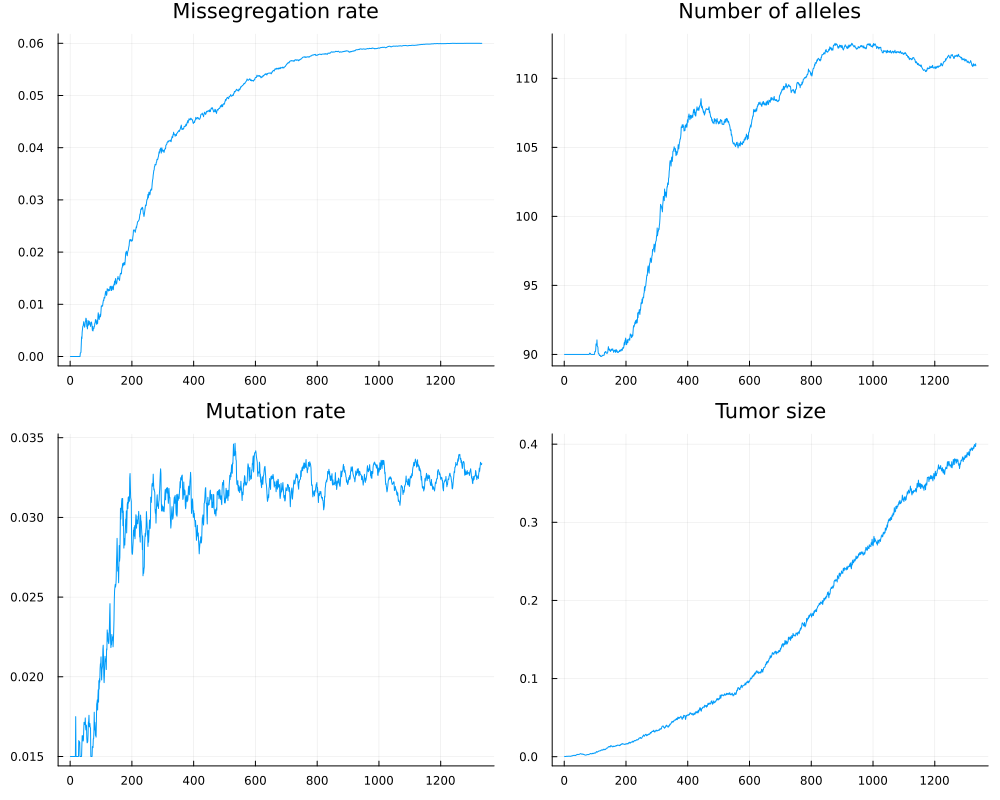

Done


In [225]:
#### Simulation ####
####################

tiss = init_tissue(L, chrom_gene_type, chrom_gene_mut, gene_map, mu0, dmu, r0, dr, 2*r0, dm)
perturb_init_tissue!(tiss, 0.01, pert_chrom_gene_mut)
res = simulation(tiss, length(chrom_gene_mut), 2500, 500, false, true, 0.4)

plot_quantities(res)
println("Done")

In [82]:
### Save to file ###
save_to_file(res.mu, "../Data/CancerEvo/single/2ch_m.txt", false)
save_to_file(res.r, "../Data/CancerEvo/single/2ch_r.txt", false)
save_to_file(res.tot_n_genes, "../Data/CancerEvo/single/2ch_ng.txt", false)
save_to_file(res.activations[1], "../Data/CancerEvo/single/2ch_ia.txt", false)
save_to_file(res.tumor_density, "../Data/CancerEvo/single/2ch_t.txt", false)

### Plots progression

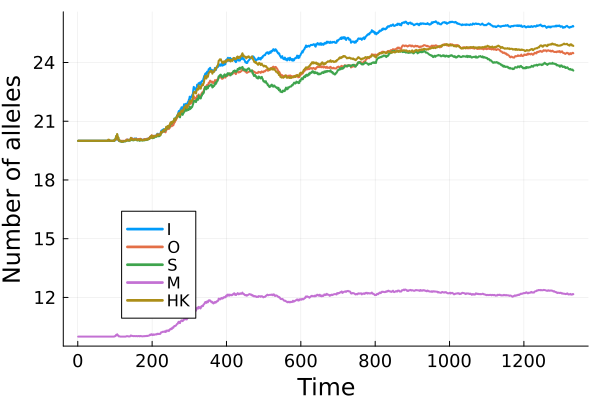

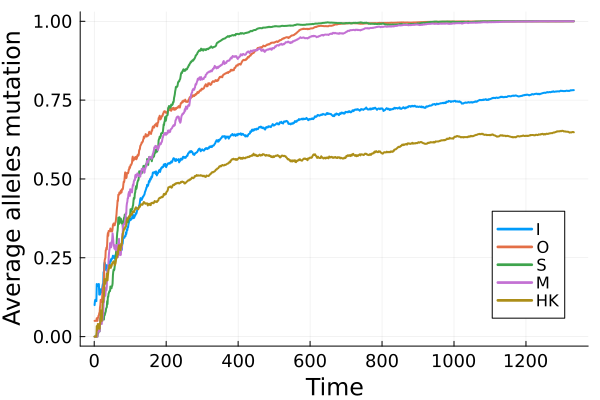

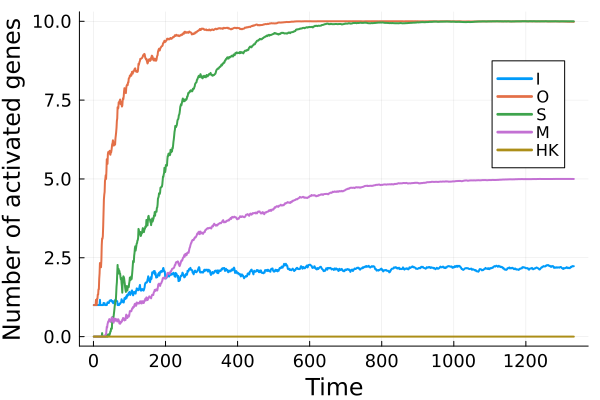

In [226]:
p_num = plot(res.n_genes_type, label=hcat("I","O","S","M","HK"), lw=2, 
     xtickfont = font(12), xguidefontsize=16, xlabel="Time",
     ytickfont = font(12), yguidefontsize=16, ylabel="Number of alleles",#ylabel="Average number act. genes",
     legendfontsize=11, legend=(0.2,0.35))
display(p_num)
#savefig("images/fig4_2ch_num.png")
p_avg = plot(res.muts, label=hcat("I","O","S","M","HK"), lw=2, 
     xtickfont = font(12), xguidefontsize=16, xlabel="Time",
     ytickfont = font(12), yguidefontsize=16, ylabel="Average alleles mutation",#ylabel="Average number act. genes",
     legendfontsize=11, legend=(0.9,0.35))
display(p_avg)
#savefig("images/fig4_2ch_avg.png")
p_act = plot(res.activations, label=hcat("I","O","S","M","HK"), lw=2, 
     xtickfont = font(12), xguidefontsize=16, xlabel="Time",
     ytickfont = font(12), yguidefontsize=16, ylabel="Number of activated genes",#ylabel="Average number act. genes",
     legendfontsize=11, legend=(0.9,0.8))
display(p_act)
#savefig("images/fig4_2ch_act.png")

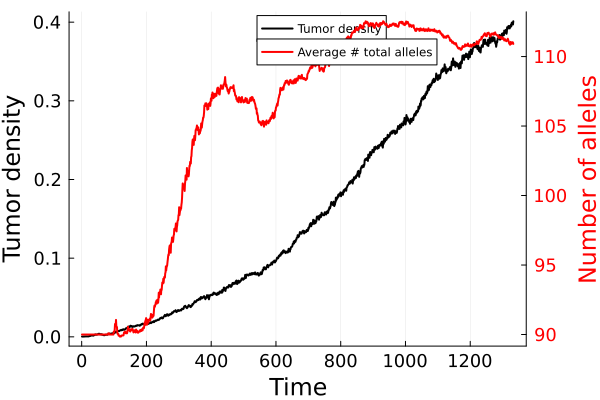

In [227]:
plot(res.tumor_density, label="Tumor density", lw=2, color="black",
     xtickfont = font(12), xguidefontsize=16, xlabel="Time",
     ytickfont = font(12), yguidefontsize=16, ylabel="Tumor density",#ylabel="Average number act. genes",
     legend=(0.5,0.95))
plot!(twinx(),res.tot_n_genes, lw=2, color="red", label="Average # total alleles", ytickfont = font(12,:red), yguidefont=font(16,:red), ylabel="Number of alleles", yguidefontsize=16, legend=(0.5,0.88))

### Statistics Plots

In [ ]:
histogram(get_Ngenes(tiss)[findall(x->x==1, get_state(tiss))], 
          normalize=:density, title="Alleles number distributions", color="tomato", 
          label="", xlabel="# alleles", ylabel="Occurrences")
vline!([N_CHR*N0_genes], color="blue", lw=3, linestyle=:dash, label="Healthy cell")
#savefig("hist_allnum.png")

In [ ]:
##### CHROMOSOME SIZE LIST #####
function chrom_size_distr(tiss::Tissue)
    
    # Create an output matrix filled with NaN.
    csize = Vector{Vector{Int}}()
    
    for i in 1:tiss.L, j in 1:tiss.L
        cell = tiss.cells[i,j]
        if cell.state == 1
            push!(csize, [length(c) for c in cell.chromosomes.chromosomes_gene_type])
        end
    end
    return flatten(csize)
end

In [ ]:
histogram(chrom_size_distr(tiss), normalize=:density, color="khaki", label="", 
          title="Chromosome size distribution", xlabel="Chromosome size", ylabel="Occourrences")
vline!([N0_genes], color="blue", lw=3, linestyle=:dash, label="Healthy cell")
#savefig("hist_allsize.png")

In [ ]:
histogram(get_Nchrs(tiss)[findall(x->x==1, get_state(tiss))], bins=2:0.5:9, normalize=:density, 
          title="Chromosome number distribution", xlabel="# chromosomes", ylabel="Occourences", label="", color="seagreen",positionss=1)
vline!([N_CHR], color="blue", lw=3, linestyle=:dash, label="Healthy cell")
#savefig("hist_chromnum.png")

In [ ]:
tis = copy_tissue(res.tissues[3])
tis.cells = tis.cells[30:130,50:150]
tis.L = 101

### Heatmaps

In [ ]:
##### HEATMAPS ######
#####################

tplot = tiss
plot_quant(tplot)
plot_gen(tplot)
plot_num_gen(tplot)
plot_activations(tplot)

In [ ]:
# saveimages for gif
c=0
mkdir("../Data/CancerEvo/gif")
for tiss in tissues
    gtype_p5 = ["I"]
    p5 = heatmap(get_avg_genemutation(tiss, gtype_p5),
                 color = :viridis,
                 clims = (0, 1),
                 title = "Mean value mutation " * join(gtype_p5, "-") * " genes",
                 xticks = false,
                 yticks = false)
    gtype_p6 = ["O"]
    p6 = heatmap(get_avg_genemutation(tiss, gtype_p6),
                 color = :viridis,
                 clims = (0, 1),
                 title = "Mean value mutation " * join(gtype_p6, "-") * " genes",
                 xticks = false,
                 yticks = false)
    gtype_p7 = ["S"]
    p7 = heatmap(get_avg_genemutation(tiss, gtype_p7),
                 color = :viridis,
                 clims = (0, 1),
                 title = "Mean value mutation " * join(gtype_p7, "-") * " genes",
                 xticks = false)
    gtype_p8 = ["HK"]
    p8 = heatmap(get_avg_genemutation(tiss, gtype_p8),
                 color = :viridis,
                 clims = (0, 1),
                 title = "Mean value mutation " * join(gtype_p8, "-") * " genes",
                 xticks = false)
    
    plot(p5, p6, p7, p8, layout = (2, 2), size = (1000, 800))
    savefig(string("../Data/CancerEvo/gif/image",c,".png"))
    c =c+1
end

In [177]:
get_gene_type(last(res.tissues), ["HK"])[89,36]

20.0

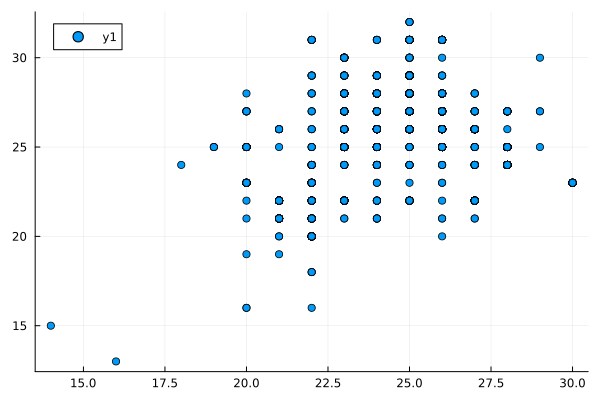

In [231]:
tcells = findall(x->x==1, get_state(last(res.tissues)))
hk = get_gene_type(last(res.tissues), ["HK"])[tcells]
i = get_gene_type(last(res.tissues), ["I"])[tcells]
scatter(hk,i)

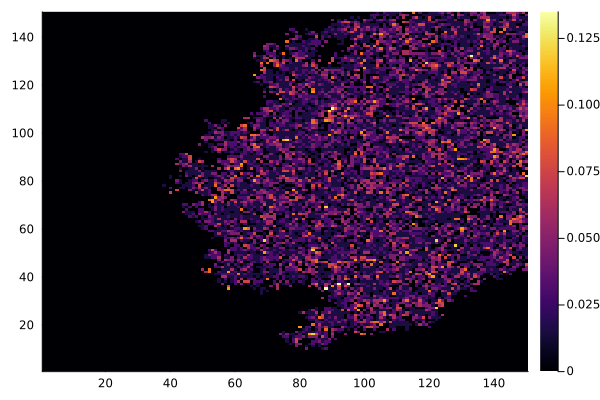

In [185]:
heatmap(get_mu(tiss))

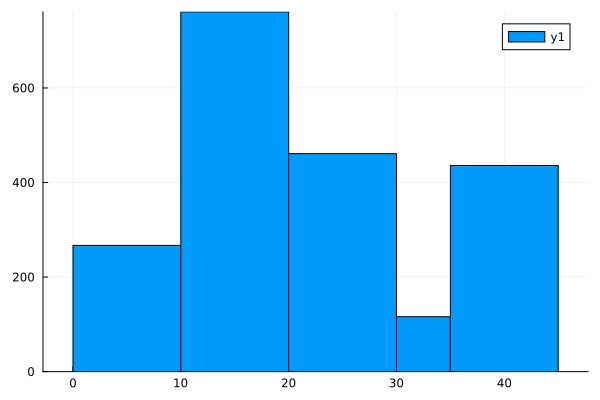

In [233]:
chrr = flatten([[t for t in tiss.cells[tc].chromosomes.chromosomes_gene_type] for tc in tcells])
l_chrr = [length(t) for t in chrr]
histogram(flatten(chrr[findall(x->x==3, l_chrr)]), bins=[0,10,20,30,35,45])

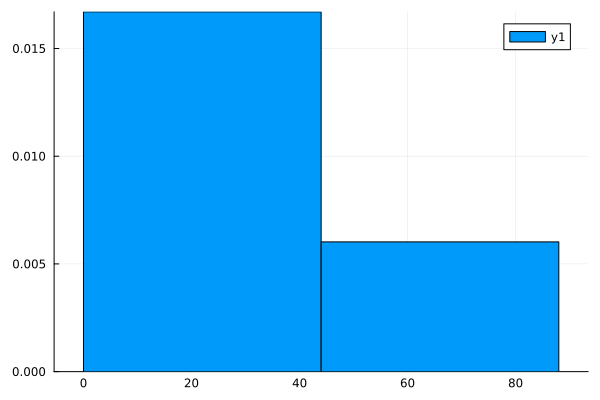

In [243]:
histogram(flatten([[length(t) for t in tiss.cells[tc].chromosomes.chromosomes_gene_mut] for tc in tcells]), bins=0:44:90, normalize=:pdf)

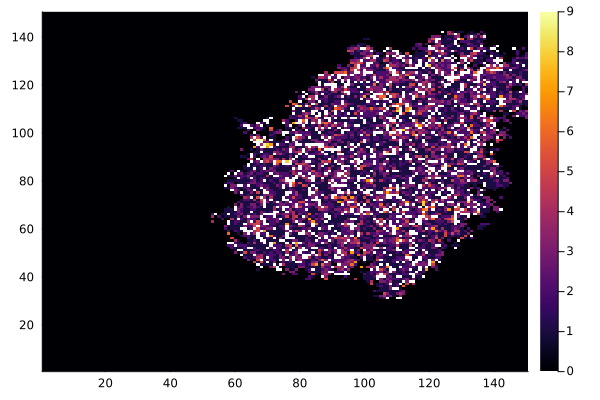

In [184]:
heatmap(get_activation_pergene(res_lim.tissues[9],"I","all"))

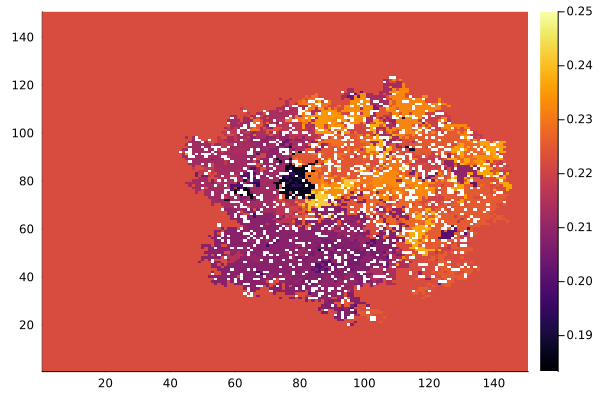

In [161]:
heatmap(get_gene_type(res_lim.tissues[9], ["I"])./get_Ngenes(res_lim.tissues[9]))

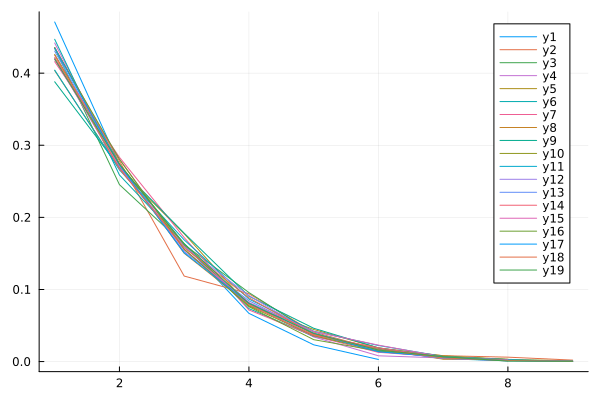

In [152]:
p = plot()
for i in 200:50:1100
    plot!(res_lim.I_populations_density[i])
end
display(p)

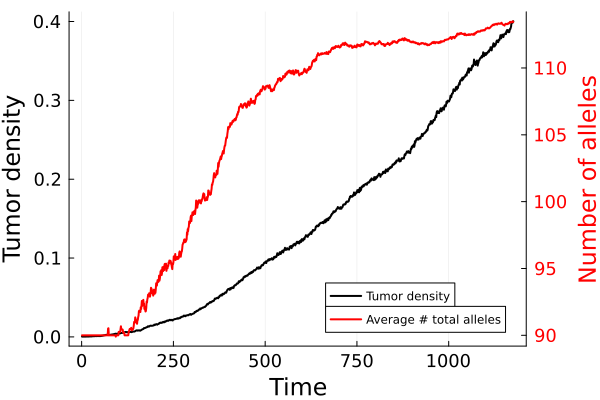

In [149]:
p = plot(res_lim.tumor_density, label="Tumor density", lw=2, color="black",
     xtickfont = font(12), xguidefontsize=16, xlabel="Time",
     ytickfont = font(12), yguidefontsize=16, ylabel="Tumor density",#ylabel="Average number act. genes",
     legend=(0.65,0.15))
plot!(twinx(),res_lim.tot_n_genes, lw=2, color="red", label="Average # total alleles", 
       ytickfont = font(12,:red), yguidefont=font(16,:red), ylabel="Number of alleles", yguidefontsize=16, 
       legend=(0.65,0.08))
display(p)
#savefig("images/fig4_2ch_tum_lim.png")

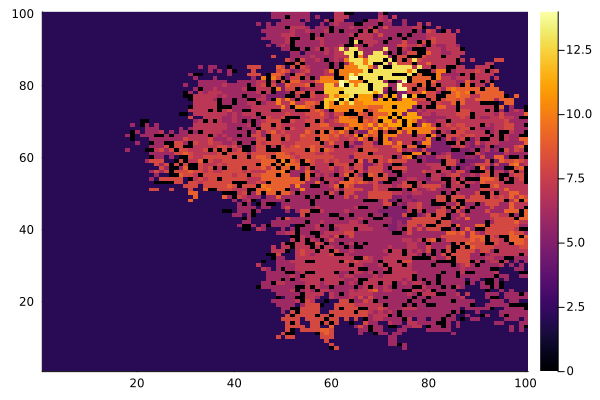

In [39]:
heatmap(get_Nchrs(tiss))

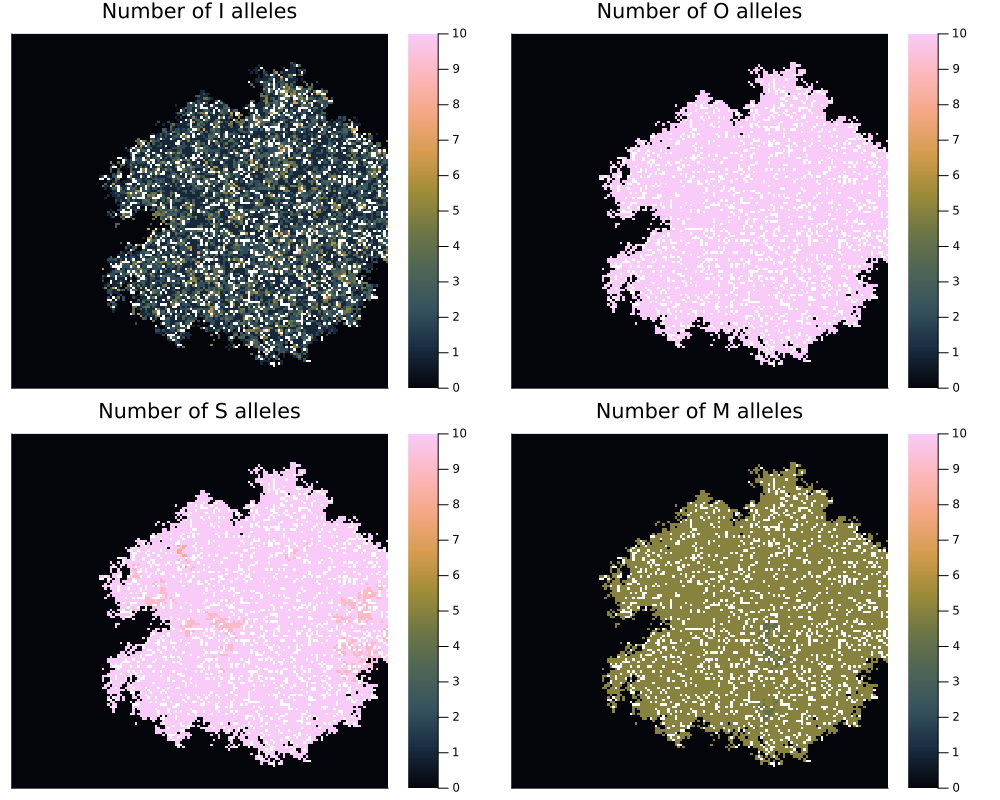

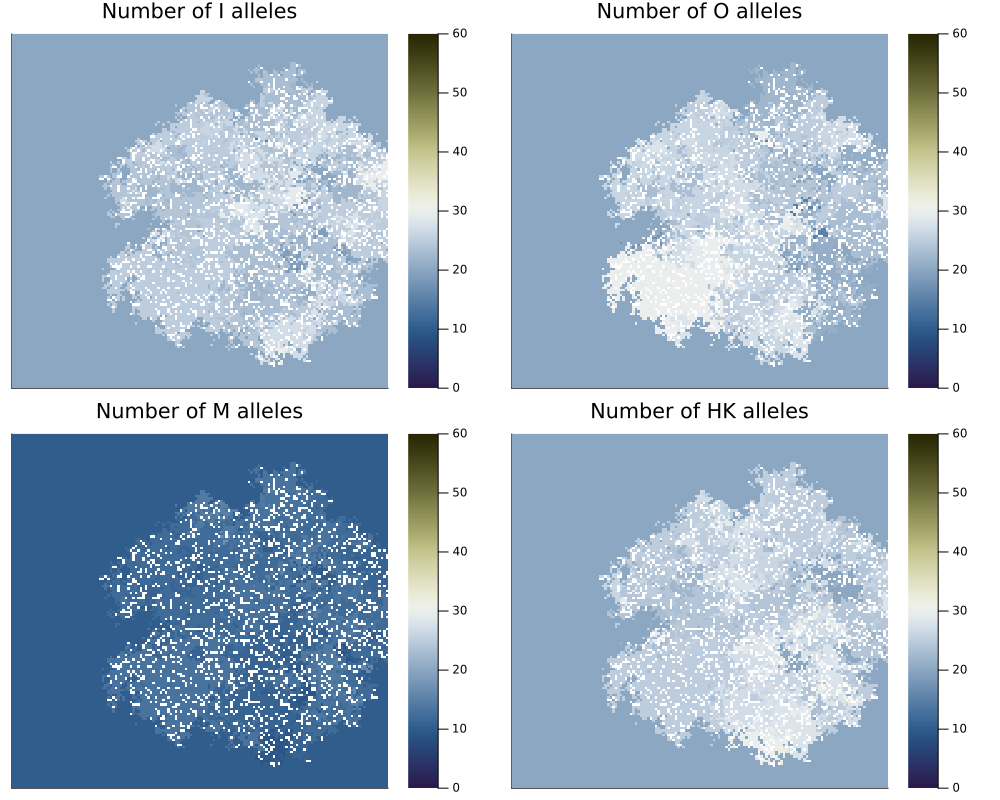

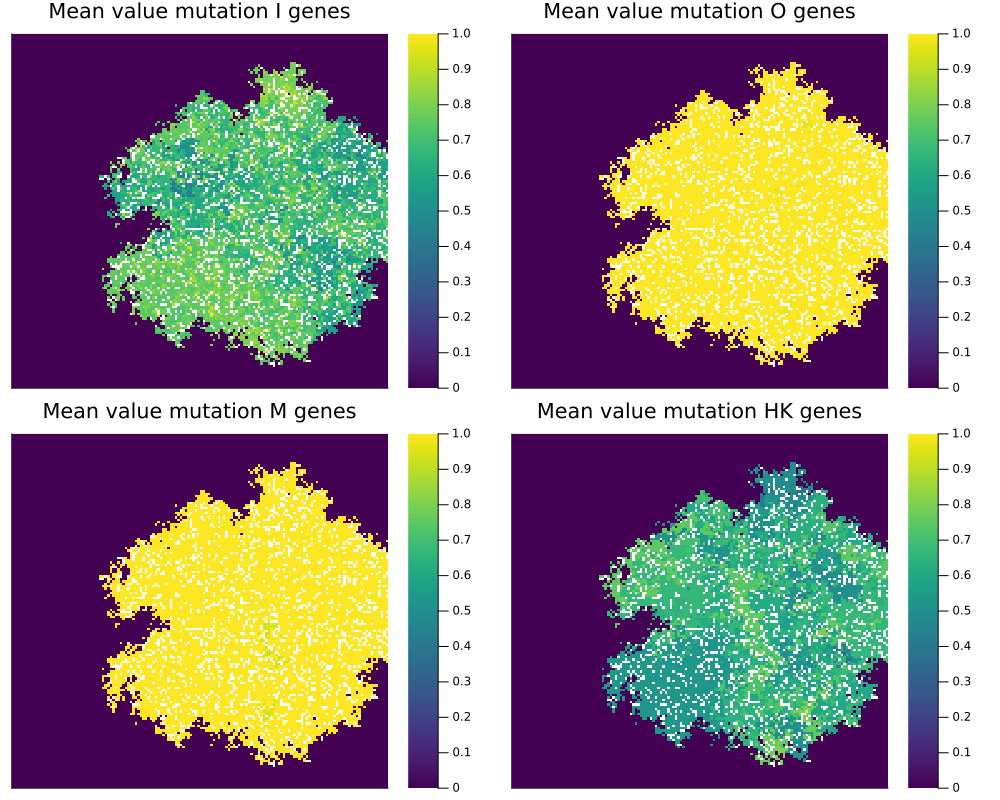

In [119]:
plot_activations(last(res_lim.tissues))
plot_num_gen(last(res_lim.tissues))
plot_gen(last(res_lim.tissues))

# Multiple repetitions

In [13]:
#### Parameters ####
###############################

#### Chromosome parameters #####
N_CHR = 2
N_I  = 10
N_O  = 10
N_S  = 10
N_M  = 5
N_HK = 10
N0_genes  = N_I+N_O+N_S+N_M+N_HK
gene_map = create_gene_map(N_I, N_O, N_S, N_M, N_HK)

#### Wild Type Chromosome ####
chrom_gene_type = fill(copy(collect(1:N0_genes)), N_CHR)
chrom_gene_mut = fill(copy(fill(0,N0_genes)), N_CHR)

#### Perturbed Chromosome ####
pert_chrom_gene_mut = Vector{Vector{Int}}()
for i in 1:N_CHR
    push!(pert_chrom_gene_mut, copy(fill(0, N0_genes)))
end

pert_chrom_gene_mut[1][1] = 1      # I genes perturbation
pert_chrom_gene_mut[2][1] = 1      # I genes perturbation
pert_chrom_gene_mut[1][1+N_I] = 1  # O genes perturbation

#### Tissue parameters ####
L       = 150
mu0     = 0.
dmu     = 15e-3
r0      = 1.5e-1
dr      = 0.7e-2
dm      = 12e-3

println("Parameters defined")

Parameters defined


In [ ]:
# Multiple repetitions
# --------------

clear_flag = false

if clear_flag
    write("../Data/CancerEvo/2ch_r.txt", "")
    write("../Data/CancerEvo/2ch_mu.txt", "")
    write("../Data/CancerEvo/2ch_state.txt", "")
    write("../Data/CancerEvo/2ch_na.txt", "")
    write("../Data/CancerEvo/2ch_aI.txt", "")
    write("../Data/CancerEvo/2ch_aO.txt", "")
    write("../Data/CancerEvo/2ch_aS.txt", "")
    write("../Data/CancerEvo/2ch_aM.txt", "")
    write("../Data/CancerEvo/2ch_nI.txt", "")
    write("../Data/CancerEvo/2ch_nO.txt", "")
    write("../Data/CancerEvo/2ch_nS.txt", "")
    write("../Data/CancerEvo/2ch_nM.txt", "")
    write("../Data/CancerEvo/2ch_nHK.txt", "")
end

nreps   = 500
#dm      = 1e-2

for nr in 1:nreps
    println("Iteration ", nr)

    tiss = init_tissue(L, chrom_gene_type, chrom_gene_mut, gene_map, mu0, dmu, r0, dr, 2*r0, dm)
    perturb_init_tissue!(tiss, 0.01, pert_chrom_gene_mut)
    res = simulation(tiss,
                      length(chrom_gene_mut), 
                      4000,
                      10000, 
                      false, 
                      false, 
                      0.4)
    println(res.state)

    # Storing quantities
    # ------------------
    open("../Data/CancerEvo/2ch_t.txt", "a") do f println(f, join(res.tumor_density, ", "))  end
    open("../Data/CancerEvo/2ch_r.txt", "a") do f println(f, join(res.r, ", "))  end
    open("../Data/CancerEvo/2ch_mu.txt", "a") do f println(f, join(res.mu, ", ")) end
    open("../Data/CancerEvo/2ch_state.txt", "a") do f println(f, join([res.state], ", ")) end
    open("../Data/CancerEvo/2ch_na.txt", "a") do f println(f, join(res.tot_n_genes, ", ")) end
    open("../Data/CancerEvo/2ch_aI.txt", "a") do f println(f, join(res.activations[1], ", ")) end
    open("../Data/CancerEvo/2ch_aO.txt", "a") do f println(f, join(res.activations[2], ", ")) end
    open("../Data/CancerEvo/2ch_aS.txt", "a") do f println(f, join(res.activations[3], ", ")) end
    open("../Data/CancerEvo/2ch_aM.txt", "a") do f println(f, join(res.activations[4], ", ")) end
    open("../Data/CancerEvo/2ch_nI.txt", "a") do f println(f, join(res.n_genes_type[1], ", ")) end
    open("../Data/CancerEvo/2ch_nO.txt", "a") do f println(f, join(res.n_genes_type[2], ", ")) end
    open("../Data/CancerEvo/2ch_nS.txt", "a") do f println(f, join(res.n_genes_type[3], ", ")) end
    open("../Data/CancerEvo/2ch_nM.txt", "a") do f println(f, join(res.n_genes_type[4], ", ")) end
    open("../Data/CancerEvo/2ch_nHK.txt", "a") do f println(f, join(res.n_genes_type[5], ", ")) end

end

Iteration 1
All normal cells at iteration 241
Health
Iteration 2

In [ ]:
# Save to file
# ------------
idx=17

open(string("../Data/CancerEvo/",idx,"_mu.txt"), "w") do io
    for row in mu_total
        println(io, join(row, ", "))  # comma-separated values
    end
end

open(string("../Data/CancerEvo/",idx,"_r.txt"), "w") do io
    for row in r_total
        println(io, join(row, ", "))  # comma-separated values
    end
end

#open(string("../Data/CancerEvo/",idx,"_state.txt"), "w") do io
#    for row in states
#        println(io, row)  # comma-separated values
#    end
#end

#open(string("../Data/CancerEvo/",idx,"_nc.txt"), "w") do io
#    for row in nc_total
#        println(io, join(row, ", "))  # comma-separated values
#    end
#end
#
#open(string("../Data/CancerEvo/",idx,"_ng.txt"), "w") do io
#    for row in ng_total
#        println(io, join(row, ", "))  # comma-separated values
#    end
#end

open(string("../Data/CancerEvo/",idx,"_c.txt"), "w") do io
    for row in tumor_total
        println(io, join(row, ", "))  # comma-separated values
    end
end

open(string("../Data/CancerEvo/",idx,"_O.txt"), "w") do io
    for row in mut_O_total
        println(io, join(row, ", "))  # comma-separated values
    end
end

open(string("../Data/CancerEvo/",idx,"_I.txt"), "w") do io
    for row in mut_I_total
        println(io, join(row, ", "))  # comma-separated values
    end
end

open(string("../Data/CancerEvo/",idx,"_S.txt"), "w") do io
    for row in mut_S_total
        println(io, join(row, ", "))  # comma-separated values
    end
end

open(string("../Data/CancerEvo/",idx,"_HK.txt"), "w") do io
    for row in mut_HK_total
        println(io, join(row, ", "))  # comma-separated values
    end
end

In [ ]:
aa = [parse(Int, r) for r in readlines("binss.txt")]

In [ ]:
tum_duration = [length(r.tumor_density) for r in res_list_2[findall(x->x.state.=="Tumor", res_list_2)]]
histogram(title="Time up to saturation", xlabel="Time", ylabel="Density")
histogram!(tum_duration, bins=0:10:600, normalize=:density, label=L"\eta=0", alpha=0.8, color="cyan")
tum_duration = [length(r.tumor_density) for r in res_list_2[findall(x->x.state.=="Health", res_list_2)]]
histogram!(tum_duration, bins=0:10:600, normalize=:density, label=L"\eta=0", alpha=0.8, color="navy")
#histogram!(aa, bins=250:50:1300, normalize=:density, label=L"\eta>0", alpha=0.8, color="navy")
#savefig("histo_tum_duration.png")

In [ ]:
histogram(get_gene_type(tiss,["I"])[findall(x->x==1, get_state(tiss))], label="I", bins=0:1:60, alpha=0.8, normalize=:density)
histogram!(get_gene_type(tiss,["O"])[findall(x->x==1, get_state(tiss))], label="O", bins=0:1:60, alpha=0.8, normalize=:density)
histogram!(get_gene_type(tiss,["S"])[findall(x->x==1, get_state(tiss))], label="S", bins=0:1:60, alpha=0.8, normalize=:density)
histogram!(get_gene_type(tiss,["M"])[findall(x->x==1, get_state(tiss))], label="M", bins=0:1:60, alpha=0.8, normalize=:density)
histogram!(get_gene_type(tiss,["HK"])[findall(x->x==1, get_state(tiss))], label="HK", bins=0:1:60, alpha=0.8, normalize=:density)
#savefig("histo_nallels.png")

In [ ]:
histogram(get_activation_pergene(tiss,"I","any")[findall(x->x==1, get_state(tiss))], label="I", bins=0:1:11, alpha=0.8)
histogram!(get_activation_pergene(tiss,"O","any")[findall(x->x==1, get_state(tiss))], label="O", bins=0:1:11, alpha=0.8)
histogram!(get_activation_pergene(tiss,"S","all")[findall(x->x==1, get_state(tiss))], label="S", bins=0:1:11, alpha=0.8)
histogram!(get_activation_pergene(tiss,"M","all")[findall(x->x==1, get_state(tiss))], label="M", bins=0:1:11, alpha=0.8)
#histogram!(get_activation_pergene(tiss,"HK","all")[findall(x->x==1, get_state(tiss))], label="HK", bins=0:1:11, alpha=0.8)

In [ ]:
final_dens = [last(r.tumor_density) for r in res_list_2]

println("Tumor %:  ", length(findall(x->x>0, final_dens))/length(res_list_2)*100)

In [ ]:
final_dens = [last(r.tumor_density) for r in res_list_4]

println("Tumor %:  ", length(findall(x->x>0, final_dens))/length(res_list_4)*100)

In [ ]:
save_to_file([r.tumors for r in res_list], "../Data/CancerEvo/tums_eta.txt", true)
save_to_file([r.mus for r in res_list], "../Data/CancerEvo/mus_eta.txt", true)
save_to_file([r.rs for r in res_list], "../Data/CancerEvo/rs_eta.txt", true)

In [ ]:
p =plot(legend=false)
for r in res_list
    plot!(r.muts_O)
end
display(p)

In [ ]:
println("Probability health: ", sum([(r.state.=="Health")/length(r.state) for r in res_list]))
println("Probability tumor: ", sum(res_list.state.=="Tumor")/length(states))
println("Probability done: ", sum(res_list.state.=="Done")/length(states))

In [ ]:
# Plot mutation trajectories #
p1 = plot(title="Cancer win", ylims=[0,1])
idx_t=findall(states.=="Tumor")[3]
plot!(mut_I_total[idx_t], label="I", lw=2)
plot!(mut_O_total[idx_t], label="O", lw=2)
plot!(mut_S_total[idx_t], label="S", lw=2)
plot!(mut_HK_total[idx_t], label="HK", lw=2)
plot!(tumor_total[idx_t], label="tumor size", lw=2)

p2 = plot(title="Cancer lose", ylims=[0,1])
idx_h=findall(states.=="Health")[1]
plot!(mut_I_total[idx_h], label="I", lw=2)
plot!(mut_O_total[idx_h], label="O", lw=2)
plot!(mut_S_total[idx_h], label="S", lw=2)
plot!(mut_HK_total[idx_h], label="HK", lw=2)
plot!(tumor_total[idx_h], label="tumor size", lw=2)

plot(p1,p2,layout=(1,2),size=(1200,500))

In [ ]:
##### BUILD PHASE DIAGRAM #####
###############################

N_I  = 10
N_O  = 10
N_S  = 10
N_HK = 10
N0_genes  = N_I+N_O+N_S+N_HK
gene_map = create_gene_map(N_I, N_O, N_S, N_HK)

chrom_gene_type = [collect(1:N0_genes), collect(1:N0_genes)]
pert_chrom_gene_type = [collect(1:N0_genes), collect(1:N0_genes)]

chrom_gene_mut = [fill(0,N0_genes), fill(0,N0_genes)]

pert_chrom_gene_mut = [fill(0,N0_genes), fill(0,N0_genes)]
pert_chrom_gene_mut[1][1] = 1
pert_chrom_gene_mut[1][1+N_I] = 1


r_prop_list = [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
objs = [0.5,0.7,1.0,1.8,2.3,2.7,3.1,3.4,3.6,3.77,3.9]
mu_list = [LinRange(o-0.4,o+0.4,6) for o in objs]

L       = 200
mu0     = 0.
dmu     = 8e-3
r0      = 2e-1
dr      = 2e-2
steps = 500

results = Float64[]
for i in 1:length(r_prop_list)
    rrr = r_prop_list[i]
    print(rrr)
    coeffs = Float64[]
    stderrs = Float64[]
    for mmm in mu_list[i]
        tiss = init_tissue(L, chrom_gene_type, chrom_gene_mut, gene_map, mu0, mmm*1e-3, r0, dr, rrr*r0)
        
        perturb_init_tissue!(tiss, 0.3, pert_chrom_gene_type, pert_chrom_gene_mut)
        
        state, tissues, mus, rs, tumors, dcells, muts_I, muts_I_std, muts_O, muts_S, muts_HK = simulation(tiss, steps,10000, false)
        
        X=(1:length(tumors))./steps; Y=tumors; data = (;X, Y)
        res = lm(@formula(Y~X), data)
        push!(coeffs, coef(res)[2])
        push!(stderrs, stderror(res)[2])
    end
    X=mu_list[i]; Y=coeffs; data = (;X, Y)
    res = lm(@formula(Y~X), data)
    push!(results, -coef(res)[1]/coef(res)[2])
end
println("Done")